<a href="https://colab.research.google.com/github/sofiiamyshelova-prog/python_for_ds_tasks/blob/main/Copy_of_HW_2_2_%D0%9B%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B7_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [64]:
import pandas as pd

In [100]:
train = pd.read_csv('/content/drive/MyDrive/ML/data/train.csv')
train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [101]:
from sklearn.model_selection import train_test_split

In [102]:
X = train.drop(columns=["Exited"])
y = train["Exited"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #розбиваємо зі збереженням пропорції цільової змінної
)

display(X_train)
display(X_val)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,7180,15652218.0,Mays,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,10393,15592937.0,Ch'eng,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,80,15774586.0,Ch'in,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,3365,15780572.0,K?,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,12236,15642099.0,Trevisani,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,9493,15711299.0,Onyekachi,633.0,France,Female,33.0,4.0,0.00,2.0,0.0,0.0,123537.05
8463,8463,15778418.0,Tsao,673.0,France,Female,40.0,1.0,0.00,1.0,1.0,1.0,47832.82
8143,8143,15585192.0,Hsia,621.0,France,Male,29.0,8.0,0.00,2.0,1.0,1.0,133535.29
11512,11512,15694450.0,Onuora,590.0,Spain,Male,42.0,7.0,0.00,2.0,0.0,0.0,72643.95


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
6490,6490,15794345.0,Pirozzi,714.0,Germany,Male,46.0,1.0,115764.32,4.0,1.0,1.0,72945.32
3646,3646,15617348.0,Ritchie,593.0,France,Male,41.0,5.0,0.00,2.0,1.0,1.0,38196.24
5306,5306,15787907.0,Hs?eh,731.0,France,Female,38.0,2.0,0.00,2.0,0.0,1.0,116971.05
652,652,15803378.0,Onio,673.0,France,Female,43.0,4.0,155739.76,1.0,0.0,1.0,111622.76
2627,2627,15772423.0,Genovesi,678.0,Spain,Female,30.0,4.0,0.00,2.0,1.0,0.0,143681.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10550,10550,15635388.0,Hsia,678.0,France,Male,38.0,4.0,0.00,2.0,1.0,0.0,133535.29
8866,8866,15589715.0,Ting,753.0,France,Male,54.0,6.0,0.00,1.0,1.0,0.0,177065.24
3244,3244,15682890.0,Okwuadigbo,678.0,Spain,Male,32.0,5.0,0.00,2.0,1.0,0.0,176712.59
12441,12441,15690188.0,Aitken,724.0,Spain,Male,33.0,5.0,138162.41,1.0,1.0,0.0,105720.09


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [103]:
input_cols=["CreditScore",
       "Geography",
       "Gender",
       "Age",
       "Tenure",
       "Balance",
       "NumOfProducts",
       "HasCrCard",
       "IsActiveMember",
       "EstimatedSalary"]

train_inputs=X_train[input_cols]
train_targets=y_train #тут вже цільова колонка, що була відокремлена раніше
val_inputs=X_val[input_cols]
val_targets=y_val

display(train_inputs)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76
...,...,...,...,...,...,...,...,...,...,...
9493,633.0,France,Female,33.0,4.0,0.00,2.0,0.0,0.0,123537.05
8463,673.0,France,Female,40.0,1.0,0.00,1.0,1.0,1.0,47832.82
8143,621.0,France,Male,29.0,8.0,0.00,2.0,1.0,1.0,133535.29
11512,590.0,Spain,Male,42.0,7.0,0.00,2.0,0.0,0.0,72643.95


3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [104]:
numeric_cols = train_inputs.select_dtypes(include='number').columns
categorical_cols = train_inputs.select_dtypes(exclude='number').columns

print(f"\nЧислові колонки: {numeric_cols}")
print(f"Категоріальні колонки: {categorical_cols}")


Числові колонки: Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')
Категоріальні колонки: Index(['Geography', 'Gender'], dtype='object')


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [105]:
# 1) перевірити чи є порожні значення - немає
# 2) за розмахом даних вирішити, чи потрібне масшабування для логістичної регресії
train_inputs.describe()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_inputs[numeric_cols] = scaler.fit_transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])


In [106]:
# 3) закодувати категоріальні

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(train_inputs[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols)
train_encoded = pd.DataFrame(
    encoder.transform(train_inputs[categorical_cols]),
    columns=encoded_cols,
    index=train_inputs.index
)
val_encoded = pd.DataFrame(
    encoder.transform(val_inputs[categorical_cols]),
    columns=encoded_cols,
    index=val_inputs.index
)

train_inputs = pd.concat(
    [train_inputs.drop(columns=categorical_cols), train_encoded],
    axis=1
)
val_inputs = pd.concat(
    [val_inputs.drop(columns=categorical_cols), val_encoded],
    axis=1
)

display(train_inputs)
display(val_inputs)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,0.320187,-0.944682,-1.447264,1.475464,-1.108193,0.515062,1.016977,0.569450,1.0,0.0,0.0,0.0,1.0
10393,0.347838,0.161227,-1.087792,2.254434,-1.108193,0.515062,-0.983306,0.603803,1.0,0.0,0.0,1.0,0.0
80,0.638166,-0.330288,0.350096,1.223831,0.769304,0.515062,-0.983306,1.238026,0.0,1.0,0.0,0.0,1.0
3365,0.140460,2.495924,-1.806736,-0.717950,0.769304,-1.941514,1.016977,-1.457116,0.0,0.0,1.0,0.0,1.0
12236,0.665816,-2.050591,-0.728320,-0.717950,0.769304,0.515062,1.016977,0.670629,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,-0.357246,-0.576046,-0.368848,-0.717950,0.769304,-1.941514,-0.983306,0.121626,1.0,0.0,0.0,1.0,0.0
8463,0.195761,0.284106,-1.447264,-0.717950,-1.108193,0.515062,1.016977,-1.539006,1.0,0.0,0.0,1.0,0.0
8143,-0.523147,-1.067561,1.069040,-0.717950,0.769304,0.515062,1.016977,0.340946,1.0,0.0,0.0,0.0,1.0
11512,-0.951727,0.529864,0.709568,-0.717950,0.769304,-1.941514,-0.983306,-0.994754,0.0,0.0,1.0,0.0,1.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6490,0.762592,1.021379,-1.447264,1.214543,4.524299,0.515062,1.016977,-0.988144,0.0,1.0,0.0,0.0,1.0
3646,-0.910252,0.406985,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.750392,1.0,0.0,0.0,0.0,1.0
5306,0.997620,0.038348,-1.087792,-0.717950,0.769304,-1.941514,1.016977,-0.022404,1.0,0.0,0.0,1.0,0.0
652,0.195761,0.652742,-0.368848,1.881867,-1.108193,-1.941514,1.016977,-0.139723,1.0,0.0,0.0,1.0,0.0
2627,0.264887,-0.944682,-0.368848,-0.717950,0.769304,0.515062,-0.983306,0.563519,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10550,0.264887,0.038348,-0.368848,-0.717950,0.769304,0.515062,-0.983306,0.340946,1.0,0.0,0.0,0.0,1.0
8866,1.301774,2.004409,0.350096,-0.717950,-1.108193,0.515062,-0.983306,1.295810,1.0,0.0,0.0,0.0,1.0
3244,0.264887,-0.698924,-0.009376,-0.717950,0.769304,0.515062,-0.983306,1.288074,0.0,0.0,1.0,0.0,1.0
12441,0.900844,-0.576046,-0.009376,1.588442,-1.108193,0.515062,-0.983306,-0.269203,0.0,0.0,1.0,0.0,1.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [72]:
!pip install pyarrow --quiet

In [107]:
%%time
train_inputs.to_parquet('train_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
val_inputs.to_parquet('val_inputs.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

CPU times: user 24.8 ms, sys: 952 µs, total: 25.8 ms
Wall time: 26.6 ms


In [108]:
train_inputs = pd.read_parquet('train_inputs.parquet')
val_inputs = pd.read_parquet('val_inputs.parquet')

train_targets = pd.read_parquet('train_targets.parquet')
val_targets = pd.read_parquet('val_targets.parquet')

print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (12000, 13)
train_targets: (12000, 1)
val_inputs: (3000, 13)
val_targets: (3000, 1)


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [109]:
X_train = train_inputs
X_val = val_inputs


In [110]:
from sklearn.linear_model import LogisticRegression

In [111]:
model = LogisticRegression(solver='liblinear')

In [112]:
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

In [113]:
train_preds = model.predict(X_train)

In [114]:
train_preds

array([0., 0., 0., ..., 0., 0., 0.])

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [115]:
from sklearn.metrics import confusion_matrix

In [116]:
confusion_matrix(train_targets, train_preds)

array([[9156,  402],
       [1103, 1339]])

In [117]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')


  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.88


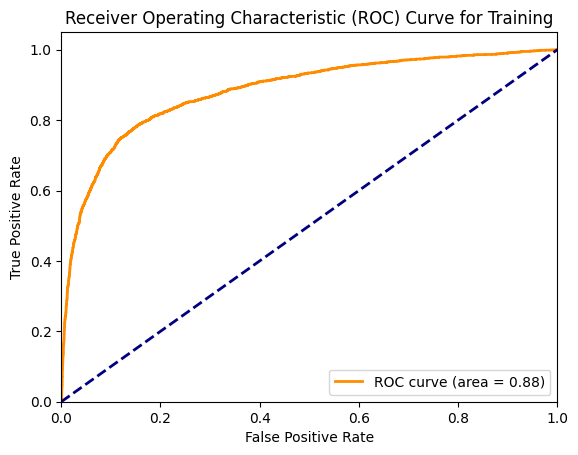

AUROC for Validation: 0.88


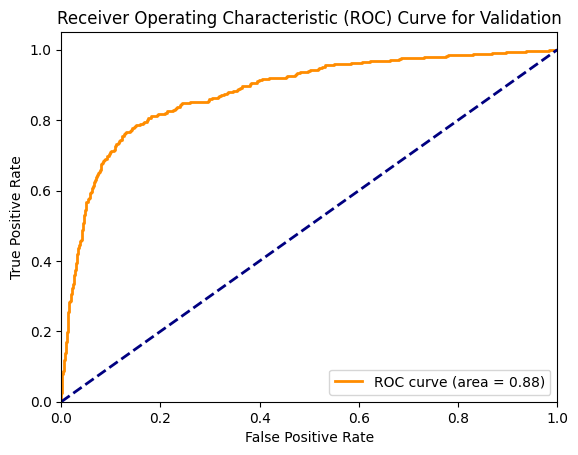

In [118]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

In [119]:
from sklearn.metrics import f1_score

In [120]:
preds = model.predict(X_train)
preds[:5], train_targets[:5]

(array([0., 0., 0., 0., 0.]),
        Exited
 7180      0.0
 10393     0.0
 80        0.0
 3365      0.0
 12236     0.0)

In [121]:
f1_score(train_targets, preds)

0.6402103753287115

In [122]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds)
  print(f"F1 score {name}: {f1_score_:.2f}")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.64
F1 score Validation: 0.64


ROC curve (area=0.88) - близтко до верхнього лівого кута - модель добре передбачає ймовірності, добре розрізняє класи, значно краща за випадкову.


F1 score Training: 0.64

F1 score Validation: 0.64

Приблизно однакові, отже модель не перенавчилась. Але погано розрізнає, де ставити межу між таргет 0 і 1.

Висновок:

Модель задовільна.

ROC = 0.88

F1 = 0.64 (train ≈ validation)

confusion matrix показує помітну кількість FN (1104) - тут великий ризик, бо клієнти пішли, а ми цього не передбачили. Краще перестрахуватись.  


8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [123]:
majority_class = y_train.mode()[0]
majority_class

np.float64(0.0)

In [124]:
import numpy as np

y_pred_train_baseline = np.zeros(len(y_train))
y_pred_val_baseline = np.zeros(len(y_val))

In [125]:
from sklearn.metrics import accuracy_score

acc_train_baseline = accuracy_score(y_train, y_pred_train_baseline)
acc_val_baseline = accuracy_score(y_val, y_pred_val_baseline)

print("Baseline Train Accuracy:", acc_train_baseline)
print("Baseline Validation Accuracy:", acc_val_baseline)

Baseline Train Accuracy: 0.7965
Baseline Validation Accuracy: 0.7966666666666666


In [126]:
y_pred_train_model = model.predict(X_train)
y_pred_val_model = model.predict(X_val)

acc_train_model = accuracy_score(y_train, y_pred_train_model)
acc_val_model = accuracy_score(y_val, y_pred_val_model)

print("Model Train Accuracy:", acc_train_model)
print("Model Validation Accuracy:", acc_val_model)

Model Train Accuracy: 0.8745833333333334
Model Validation Accuracy: 0.8696666666666667


Логістична регресія показала Accuracy 0.8745 на тренувальній та 0.8697 на валідаційній вибірці, що суттєво перевищує якість baseline-моделі, яка завжди прогнозує мажоритарний клас.

Загалом якість моделі можна оцінити як хорошу

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [127]:
import joblib

joblib.dump(model, "log_reg.joblib")

['log_reg.joblib']

In [128]:
model_2 = joblib.load("log_reg.joblib")

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [149]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df):
    input_df = input_df.copy()
    numeric_cols = list(numeric_cols)
    encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    input_df = input_df.drop(columns=categorical_cols)
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [150]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, train[:5])

array([0.00563657, 0.03331576, 0.3809349 , 0.38052591, 0.97925368])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [151]:
test_raw_df = pd.read_csv('/content/drive/MyDrive/ML/data/test.csv')
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [152]:
probs = predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, test_raw_df)

test_raw_df["Exited"] = probs

test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.069393
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.033314
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.153586
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.199192
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.054281


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [153]:
sample_submission = pd.read_csv('/content/drive/MyDrive/ML/data/sample_submission.csv')
sample_submission.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [155]:
sample_submission["Exited"] = probs
print(sample_submission.head())

      id    Exited
0  15000  0.069393
1  15001  0.033314
2  15002  0.153586
3  15003  0.199192
4  15004  0.054281


In [156]:
sample_submission.to_csv("submission_log_reg.csv", index=False)